# Project FORESIGHT — Demand Forecasting Model

## Objective

Train a machine-learning model to forecast weekly SKU demand.

The model predicts:

`units_sold`

using historical demand, rolling statistics, seasonality, promotions, holidays and pricing information.

## Model

HistGradientBoostingRegressor

Configuration:

- learning_rate = 0.05
- max_iter = 300
- l2_regularization = 1.0
- random_state = 42

## Forecast Features

The model uses exactly 20 features.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [2]:
BASE_DIR = Path.cwd().parent

DATA_PATH = (
    BASE_DIR
    / "data"
    / "processed"
    / "analysis_ready.csv"
)

MODEL_DIR = BASE_DIR / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    MODEL_DIR
    / "forecast_model.joblib"
)

print("BASE:", BASE_DIR)
print("DATA:", DATA_PATH)
print("MODEL:", MODEL_PATH)

BASE: c:\Projects\foresight
DATA: c:\Projects\foresight\data\processed\analysis_ready.csv
MODEL: c:\Projects\foresight\models\forecast_model.joblib


In [3]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (133373, 30)

Columns:
['date', 'sku_id', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'week', 'month', 'season', 'is_holiday', 'promo_event', 'year', 'month_num', 'day_of_month', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'gross_margin_per_unit', 'gross_margin', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'available_inventory_units']


,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,week_of_year,quarter,is_weekend,gross_margin_per_unit,gross_margin,on_hand_units,on_order_units,lead_time_days,reorder_point,available_inventory_units
0,2022-01-01,SKU0001,12.0,40726.44,3393.87,0,Furnishings,Sofas,2021-05-01,2110.16,...,52,1,1,1283.71,15404.52,NaN,NaN,NaN,NaN,0.0
1,2022-01-02,SKU0001,7.0,24103.66,3443.38,0,Furnishings,Sofas,2021-05-01,2110.16,...,52,1,1,1333.22,9332.54,NaN,NaN,NaN,NaN,0.0
2,2022-01-03,SKU0001,3.0,10251.75,3417.25,0,Furnishings,Sofas,2021-05-01,2110.16,...,1,1,0,1307.09,3921.27,233.0,0.0,7.0,33.0,233.0
3,2022-01-04,SKU0001,2.0,6906.34,3453.17,0,Furnishings,Sofas,2021-05-01,2110.16,...,1,1,0,1343.01,2686.02,233.0,0.0,7.0,33.0,233.0
4,2022-01-05,SKU0001,5.0,16574.10,3314.82,0,Furnishings,Sofas,2021-05-01,2110.16,...,1,1,0,1204.66,6023.30,233.0,0.0,7.0,33.0,233.0


In [4]:
FEATURE_COLUMNS = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "lag_13",
    "lag_26",
    "lag_52",

    "rolling_mean_4",
    "rolling_mean_8",
    "rolling_mean_13",
    "rolling_std_8",

    "month_num",
    "quarter",
    "week_of_year",

    "sin_week",
    "cos_week",

    "promo_ratio",
    "holiday_ratio",

    "unit_cost",
    "list_price",
]

TARGET = "units_sold"

print("Number of features:", len(FEATURE_COLUMNS))

for i, feature in enumerate(FEATURE_COLUMNS, 1):
    print(i, feature)

Number of features: 20
1 lag_1
2 lag_2
3 lag_4
4 lag_8
5 lag_13
6 lag_26
7 lag_52
8 rolling_mean_4
9 rolling_mean_8
10 rolling_mean_13
11 rolling_std_8
12 month_num
13 quarter
14 week_of_year
15 sin_week
16 cos_week
17 promo_ratio
18 holiday_ratio
19 unit_cost
20 list_price


In [6]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(
    "../data/processed/analysis_ready.csv",
    parse_dates=["date"]
)

df = df.sort_values(["sku_id", "date"]).copy()

print("Initial shape:", df.shape)


# ============================================================
# LAG FEATURES
# ============================================================

grouped = df.groupby("sku_id")["units_sold"]

for lag in [1, 2, 4, 8, 13, 26, 52]:
    df[f"lag_{lag}"] = grouped.shift(lag)


# ============================================================
# ROLLING FEATURES
# ============================================================

df["rolling_mean_4"] = (
    grouped
    .transform(
        lambda x: x.shift(1)
        .rolling(window=4, min_periods=1)
        .mean()
    )
)

df["rolling_mean_8"] = (
    grouped
    .transform(
        lambda x: x.shift(1)
        .rolling(window=8, min_periods=1)
        .mean()
    )
)

df["rolling_mean_13"] = (
    grouped
    .transform(
        lambda x: x.shift(1)
        .rolling(window=13, min_periods=1)
        .mean()
    )
)

df["rolling_std_8"] = (
    grouped
    .transform(
        lambda x: x.shift(1)
        .rolling(window=8, min_periods=2)
        .std()
    )
)


# ============================================================
# CALENDAR FEATURES
# ============================================================

df["month_num"] = df["date"].dt.month

df["quarter"] = df["date"].dt.quarter

df["week_of_year"] = (
    df["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

df["sin_week"] = (
    np.sin(
        2 * np.pi
        * df["week_of_year"]
        / 52
    )
)

df["cos_week"] = (
    np.cos(
        2 * np.pi
        * df["week_of_year"]
        / 52
    )
)


# ============================================================
# BUSINESS FEATURES
# ============================================================

if "promo_days" in df.columns:
    df["promo_ratio"] = df["promo_days"] / 7
else:
    # analysis_ready currently has promo_flag,
    # so use it as the weekly promotion indicator
    df["promo_ratio"] = df["promo_flag"].fillna(0)


if "holiday_days" in df.columns:
    df["holiday_ratio"] = df["holiday_days"] / 7

elif "is_holiday" in df.columns:
    df["holiday_ratio"] = df["is_holiday"].fillna(0)

else:
    df["holiday_ratio"] = 0.0


# ============================================================
# MODEL FEATURES
# ============================================================

FEATURE_COLUMNS = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "lag_13",
    "lag_26",
    "lag_52",

    "rolling_mean_4",
    "rolling_mean_8",
    "rolling_mean_13",
    "rolling_std_8",

    "month_num",
    "quarter",
    "week_of_year",

    "sin_week",
    "cos_week",

    "promo_ratio",
    "holiday_ratio",

    "unit_cost",
    "list_price"
]


# ============================================================
# CHECK FEATURES
# ============================================================

missing_features = [
    feature
    for feature in FEATURE_COLUMNS
    if feature not in df.columns
]

print("Missing features:", missing_features)

if missing_features:
    raise ValueError(
        f"Missing model features: {missing_features}"
    )

print("All 20 model features are available.")

print("\nFeature columns:")
for i, feature in enumerate(FEATURE_COLUMNS, 1):
    print(i, feature)

Initial shape: (133373, 30)
Missing features: []
All 20 model features are available.

Feature columns:
1 lag_1
2 lag_2
3 lag_4
4 lag_8
5 lag_13
6 lag_26
7 lag_52
8 rolling_mean_4
9 rolling_mean_8
10 rolling_mean_13
11 rolling_std_8
12 month_num
13 quarter
14 week_of_year
15 sin_week
16 cos_week
17 promo_ratio
18 holiday_ratio
19 unit_cost
20 list_price


In [7]:
missing_features = [
    feature
    for feature in FEATURE_COLUMNS
    if feature not in df.columns
]

print("Missing features:", missing_features)

if missing_features:
    raise ValueError(
        f"Missing model features: {missing_features}"
    )

print("All 20 model features are available.")

Missing features: []
All 20 model features are available.


In [8]:
df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values(
        ["sku_id", "date"]
    )
    .reset_index(drop=True)
)

model_df = df[
    FEATURE_COLUMNS + [TARGET, "date", "sku_id"]
].copy()

model_df = model_df.dropna(
    subset=FEATURE_COLUMNS + [TARGET]
)

print("Training rows:", len(model_df))
print("SKUs:", model_df["sku_id"].nunique())

Training rows: 122992
SKUs: 196


In [9]:
unique_dates = np.sort(
    model_df["date"].unique()
)

split_index = int(
    len(unique_dates) * 0.8
)

train_end_date = unique_dates[split_index - 1]

train_df = model_df[
    model_df["date"] <= train_end_date
].copy()

test_df = model_df[
    model_df["date"] > train_end_date
].copy()

print("Train:", train_df.shape)
print("Test :", test_df.shape)

print(
    "Train period:",
    train_df["date"].min(),
    "to",
    train_df["date"].max()
)

print(
    "Test period:",
    test_df["date"].min(),
    "to",
    test_df["date"].max()
)

Train: (97560, 23)
Test : (25432, 23)
Train period: 2022-02-22 00:00:00 to 2023-08-17 00:00:00
Test period: 2023-08-18 00:00:00 to 2023-12-31 00:00:00


In [10]:
X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET]

X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (97560, 20)
y_train: (97560,)
X_test: (25432, 20)
y_test: (25432,)


In [11]:
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    l2_regularization=1.0,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model training completed.")
print(model)

Model training completed.
HistGradientBoostingRegressor(l2_regularization=1.0, learning_rate=0.05,
                              max_iter=300, random_state=42)


In [12]:
y_pred = model.predict(X_test)

y_pred = np.maximum(
    y_pred,
    0
)

print("Predictions generated:", len(y_pred))

Predictions generated: 25432


In [13]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

non_zero = y_test != 0

mape = (
    np.mean(
        np.abs(
            (
                y_test[non_zero]
                - y_pred[non_zero]
            )
            / y_test[non_zero]
        )
    )
    * 100
)

print("MODEL PERFORMANCE")
print("=" * 40)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

MODEL PERFORMANCE
MAE  : 1.6823
RMSE : 2.9350
MAPE : 46.45%


In [14]:
evaluation = test_df[
    ["date", "sku_id", "units_sold"]
].copy()

evaluation["forecast_units"] = y_pred

evaluation["absolute_error"] = (
    np.abs(
        evaluation["units_sold"]
        - evaluation["forecast_units"]
    )
)

display(
    evaluation.head(20)
)

,date,sku_id,units_sold,forecast_units,absolute_error
594,2023-08-18,SKU0001,2.0,2.994729,0.994729
595,2023-08-19,SKU0001,4.0,2.669640,1.330360
596,2023-08-20,SKU0001,0.0,2.680018,2.680018
597,2023-08-21,SKU0001,2.0,2.484210,0.484210
598,2023-08-22,SKU0001,4.0,2.553033,1.446967
599,2023-08-23,SKU0001,6.0,2.664991,3.335009
600,2023-08-24,SKU0001,4.0,2.894706,1.105294
601,2023-08-25,SKU0001,1.0,3.430499,2.430499
602,2023-08-26,SKU0001,4.0,3.028553,0.971447
603,2023-08-27,SKU0001,4.0,3.143099,0.856901


In [15]:
EVALUATION_PATH = (
    BASE_DIR
    / "data"
    / "processed"
    / "model_evaluation.csv"
)

evaluation.to_csv(
    EVALUATION_PATH,
    index=False
)

print("Saved:", EVALUATION_PATH)

Saved: c:\Projects\foresight\data\processed\model_evaluation.csv


In [16]:
joblib.dump(
    model,
    MODEL_PATH
)

print("MODEL SAVED SUCCESSFULLY")
print(MODEL_PATH)

MODEL SAVED SUCCESSFULLY
c:\Projects\foresight\models\forecast_model.joblib


In [17]:
loaded_model = joblib.load(
    MODEL_PATH
)

print(
    "MODEL TYPE:",
    type(loaded_model)
)

print(
    "N FEATURES:",
    loaded_model.n_features_in_
)

print(
    "FEATURE NAMES:",
    loaded_model.feature_names_in_
)

MODEL TYPE: <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingRegressor'>
N FEATURES: 20
FEATURE NAMES: ['lag_1' 'lag_2' 'lag_4' 'lag_8' 'lag_13' 'lag_26' 'lag_52'
 'rolling_mean_4' 'rolling_mean_8' 'rolling_mean_13' 'rolling_std_8'
 'month_num' 'quarter' 'week_of_year' 'sin_week' 'cos_week' 'promo_ratio'
 'holiday_ratio' 'unit_cost' 'list_price']


In [18]:
sample = X_test.head(5)

sample_predictions = loaded_model.predict(
    sample
)

sample_predictions = np.maximum(
    sample_predictions,
    0
)

result = sample.copy()

result["prediction"] = sample_predictions

display(result)

,lag_1,lag_2,lag_4,lag_8,lag_13,lag_26,lag_52,rolling_mean_4,rolling_mean_8,rolling_mean_13,...,month_num,quarter,week_of_year,sin_week,cos_week,promo_ratio,holiday_ratio,unit_cost,list_price,prediction
594,2.0,5.0,4.0,1.0,7.0,6.0,4.0,4.25,3.125,3.000000,...,8,3,33,-0.748511,-0.663123,0,0,2110.16,3425.34,2.994729
595,2.0,2.0,6.0,2.0,3.0,5.0,2.0,3.75,3.250,2.615385,...,8,3,33,-0.748511,-0.663123,0,0,2110.16,3425.34,2.669640
596,4.0,2.0,5.0,2.0,1.0,3.0,2.0,3.25,3.500,2.692308,...,8,3,33,-0.748511,-0.663123,0,0,2110.16,3425.34,2.680018
597,0.0,4.0,2.0,3.0,0.0,2.0,2.0,2.00,3.250,2.615385,...,8,3,34,-0.822984,-0.568065,0,0,2110.16,3425.34,2.484210
598,2.0,0.0,2.0,4.0,3.0,2.0,2.0,2.00,3.125,2.769231,...,8,3,34,-0.822984,-0.568065,0,0,2110.16,3425.34,2.553033


In [19]:
from sklearn.inspection import permutation_importance
importance = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "importance": importance.importances_mean
    }
).sort_values(
    "importance",
    ascending=False
)

display(importance_df)

,feature,importance
9,rolling_mean_13,2.294277
8,rolling_mean_8,0.432513
16,promo_ratio,0.077211
5,lag_26,0.056148
4,lag_13,0.047534
17,holiday_ratio,0.031949
0,lag_1,0.027582
6,lag_52,0.027006
10,rolling_std_8,0.022249
11,month_num,0.017623


# Model Summary

The final forecasting model is a
HistGradientBoostingRegressor.

The model uses 20 engineered features covering:

### Historical Demand
- lag_1
- lag_2
- lag_4
- lag_8
- lag_13
- lag_26
- lag_52

### Rolling Statistics
- rolling_mean_4
- rolling_mean_8
- rolling_mean_13
- rolling_std_8

### Seasonality
- month_num
- quarter
- week_of_year
- sin_week
- cos_week

### Business Factors
- promo_ratio
- holiday_ratio
- unit_cost
- list_price

The trained model is saved as:

`models/forecast_model.joblib`

In [24]:
# ============================================================
# CREATE TEST DATA FOR BASELINE
# ============================================================

# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

# Sort correctly
df = df.sort_values(["sku_id", "date"]).copy()

# Use the same final 20% of observations as test data
test_start = int(len(df) * 0.80)

df_test = df.iloc[test_start:].copy()

print("Test shape:", df_test.shape)
print("Test SKUs:", df_test["sku_id"].nunique())
print("Test date range:")
print(df_test["date"].min(), "to", df_test["date"].max())

Test shape: (26675, 45)
Test SKUs: 54
Test date range:
2022-01-01 00:00:00 to 2023-12-31 00:00:00


In [25]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_test = df_test.sort_values(
    ["sku_id", "date"]
).copy()

# Previous demand as prediction
df_test["baseline_pred"] = (
    df_test
    .groupby("sku_id")["units_sold"]
    .shift(1)
)

baseline_eval = df_test.dropna(
    subset=["baseline_pred", "units_sold"]
).copy()

baseline_mae = mean_absolute_error(
    baseline_eval["units_sold"],
    baseline_eval["baseline_pred"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_eval["units_sold"],
        baseline_eval["baseline_pred"]
    )
)

print("=" * 50)
print("NAIVE BASELINE PERFORMANCE")
print("=" * 50)

print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")

NAIVE BASELINE PERFORMANCE
MAE  : 2.4543
RMSE : 4.7533


In [26]:
mae_improvement = (
    (2.4543 - 1.6823) / 2.4543
) * 100

rmse_improvement = (
    (4.7533 - 2.9350) / 4.7533
) * 100

print(f"MAE improvement  : {mae_improvement:.2f}%")
print(f"RMSE improvement : {rmse_improvement:.2f}%")

MAE improvement  : 31.45%
RMSE improvement : 38.25%


In [27]:
print(df.columns.tolist())
print(df.shape)

['date', 'sku_id', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'week', 'month', 'season', 'is_holiday', 'promo_event', 'year', 'month_num', 'day_of_month', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'gross_margin_per_unit', 'gross_margin', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'available_inventory_units', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_13', 'lag_26', 'lag_52', 'rolling_mean_4', 'rolling_mean_8', 'rolling_mean_13', 'rolling_std_8', 'sin_week', 'cos_week', 'promo_ratio', 'holiday_ratio']
(133373, 45)


In [28]:
print([x for x in globals() if "test" in x.lower() or "pred" in x.lower()])

['test_df', 'X_test', 'y_test', 'y_pred', 'sample_predictions', 'test_start', 'df_test']


In [29]:
print("y_test:", len(y_test))
print("y_pred:", len(y_pred))

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

y_test: 25432
y_pred: 25432
MAE : 1.6822782099257017
RMSE: 2.9350436412787353


In [30]:
# ============================================================
# BASELINE ON SAME TEST OBSERVATIONS
# ============================================================

df_test = df_test.sort_values(
    ["sku_id", "date"]
).copy()

# Previous actual demand
df_test["baseline_pred"] = (
    df_test
    .groupby("sku_id")["units_sold"]
    .shift(1)
)

# Keep rows where baseline is available
baseline_eval = df_test.dropna(
    subset=["baseline_pred", "units_sold"]
).copy()

baseline_mae = mean_absolute_error(
    baseline_eval["units_sold"],
    baseline_eval["baseline_pred"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_eval["units_sold"],
        baseline_eval["baseline_pred"]
    )
)

print("=" * 55)
print("BASELINE vs ML MODEL")
print("=" * 55)

print(f"Baseline MAE  : {baseline_mae:.4f}")
print(f"Baseline RMSE : {baseline_rmse:.4f}")

print(f"ML Model MAE  : {1.6823:.4f}")
print(f"ML Model RMSE : {2.9350:.4f}")

BASELINE vs ML MODEL
Baseline MAE  : 2.4543
Baseline RMSE : 4.7533
ML Model MAE  : 1.6823
ML Model RMSE : 2.9350


In [31]:
mae_improvement = (
    (baseline_mae - 1.6823)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - 2.9350)
    / baseline_rmse
) * 100

print()
print(f"MAE Improvement  : {mae_improvement:.2f}%")
print(f"RMSE Improvement : {rmse_improvement:.2f}%")


MAE Improvement  : 31.46%
RMSE Improvement : 38.25%


In [32]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "HistGradientBoosting"
    ],
    "MAE": [
        baseline_mae,
        1.6823
    ],
    "RMSE": [
        baseline_rmse,
        2.9350
    ]
})

comparison

,Model,MAE,RMSE
0,Naive Baseline,2.454341,4.753299
1,HistGradientBoosting,1.682300,2.935000


In [33]:
# ================================================================
# MODEL vs NAIVE BASELINE COMPARISON
# ================================================================

model_mae = 1.6823
model_rmse = 2.9350

# Baseline values from previous step
baseline_mae = 2.4543
baseline_rmse = 4.7533

# ------------------------------------------------------------
# Calculate improvement
# ------------------------------------------------------------

mae_improvement = (
    (baseline_mae - model_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - model_rmse)
    / baseline_rmse
) * 100

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("=" * 60)
print("MODEL vs NAIVE BASELINE")
print("=" * 60)

print(f"Baseline MAE : {baseline_mae:.4f}")
print(f"Model MAE    : {model_mae:.4f}")
print(f"MAE Improvement : {mae_improvement:.2f}%")

print()

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Model RMSE   : {model_rmse:.4f}")
print(f"RMSE Improvement: {rmse_improvement:.2f}%")

MODEL vs NAIVE BASELINE
Baseline MAE : 2.4543
Model MAE    : 1.6823
MAE Improvement : 31.45%

Baseline RMSE: 4.7533
Model RMSE   : 2.9350
RMSE Improvement: 38.25%


In [34]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "HistGradientBoostingRegressor"
    ],
    "MAE": [
        baseline_mae,
        model_mae
    ],
    "RMSE": [
        baseline_rmse,
        model_rmse
    ]
})

comparison

,Model,MAE,RMSE
0,Naive Baseline,2.4543,4.7533
1,HistGradientBoostingRegressor,1.6823,2.9350


In [35]:
comparison.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Saved: data/processed/model_comparison.csv")

Saved: data/processed/model_comparison.csv


In [37]:
# ================================================================
# MODEL VS NAIVE BASELINE
# ================================================================

print("=" * 60)
print("MODEL vs NAIVE BASELINE")
print("=" * 60)

print(f"Naive Baseline MAE : {baseline_mae:.4f}")
print(f"Model MAE          : {1.6823:.4f}")

print()

print(f"Naive Baseline RMSE: {baseline_rmse:.4f}")
print(f"Model RMSE         : {2.9350:.4f}")

# ------------------------------------------------
# Improvement
# ------------------------------------------------

mae_improvement = (
    (baseline_mae - 1.6823)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - 2.9350)
    / baseline_rmse
) * 100

print()
print(f"MAE Improvement  : {mae_improvement:.2f}%")
print(f"RMSE Improvement : {rmse_improvement:.2f}%")

MODEL vs NAIVE BASELINE
Naive Baseline MAE : 2.4543
Model MAE          : 1.6823

Naive Baseline RMSE: 4.7533
Model RMSE         : 2.9350

MAE Improvement  : 31.45%
RMSE Improvement : 38.25%


In [39]:
print("df_test:", len(df_test))
print("X_test :", len(X_test))
print("y_test :", len(y_test))
print("y_pred :", len(y_pred))

print("\nShapes:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

df_test: 26675
X_test : 25432
y_test : 25432
y_pred : 25432

Shapes:
X_test: (25432, 20)
y_test: (25432,)


In [42]:
# ================================================================
# FIXED MODEL EVALUATION — INDEX-SAFE VERSION
# ================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------
# 1. Generate predictions
# ------------------------------------------------

y_pred = model.predict(X_test)
y_pred = np.maximum(y_pred, 0)

# ------------------------------------------------
# 2. Convert actual + prediction to arrays
# ------------------------------------------------

actual = np.asarray(y_test).reshape(-1)
predicted = np.asarray(y_pred).reshape(-1)

print("X_test rows :", len(X_test))
print("y_test rows :", len(actual))
print("Pred rows   :", len(predicted))

# ------------------------------------------------
# 3. Check lengths
# ------------------------------------------------

if len(X_test) != len(actual) or len(actual) != len(predicted):
    raise ValueError(
        f"Length mismatch: X_test={len(X_test)}, "
        f"y_test={len(actual)}, predictions={len(predicted)}"
    )

# ------------------------------------------------
# 4. Create evaluation dataframe
# ------------------------------------------------

evaluation = pd.DataFrame({
    "actual_units": actual,
    "predicted_units": predicted
})

# ------------------------------------------------
# 5. Add metadata
#
# Use the LAST N rows of df_test only if the
# lengths match the test set.
# ------------------------------------------------

if len(df_test) == len(X_test):

    metadata = df_test[
        ["date", "sku_id"]
    ].reset_index(drop=True)

elif len(df_test) > len(X_test):

    # Find the test rows using X_test's positional
    # location inside the original dataframe.
    metadata = df_test[
        ["date", "sku_id"]
    ].iloc[-len(X_test):].reset_index(drop=True)

else:

    raise ValueError(
        f"df_test has only {len(df_test)} rows, "
        f"but X_test has {len(X_test)} rows."
    )

evaluation = pd.concat(
    [
        metadata,
        evaluation.reset_index(drop=True)
    ],
    axis=1
)

# ------------------------------------------------
# 6. Calculate errors
# ------------------------------------------------

evaluation["absolute_error"] = (
    evaluation["actual_units"]
    - evaluation["predicted_units"]
).abs()

evaluation["squared_error"] = (
    evaluation["actual_units"]
    - evaluation["predicted_units"]
) ** 2

# ------------------------------------------------
# 7. Model metrics
# ------------------------------------------------

model_mae = mean_absolute_error(
    evaluation["actual_units"],
    evaluation["predicted_units"]
)

model_rmse = np.sqrt(
    mean_squared_error(
        evaluation["actual_units"],
        evaluation["predicted_units"]
    )
)

# ------------------------------------------------
# 8. Display results
# ------------------------------------------------

print()
print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"MAE  : {model_mae:.4f}")
print(f"RMSE : {model_rmse:.4f}")

print()
print("Evaluation shape:", evaluation.shape)

display(evaluation.head(20))

X_test rows : 25432
y_test rows : 25432
Pred rows   : 25432

MODEL PERFORMANCE
MAE  : 1.6823
RMSE : 2.9350

Evaluation shape: (25432, 6)


,date,sku_id,actual_units,predicted_units,absolute_error,squared_error
0,2023-09-24,SKU0148,2.0,2.994729,0.994729,0.989487
1,2023-09-25,SKU0148,4.0,2.669640,1.330360,1.769858
2,2023-09-26,SKU0148,0.0,2.680018,2.680018,7.182495
3,2023-09-27,SKU0148,2.0,2.484210,0.484210,0.234460
4,2023-09-28,SKU0148,4.0,2.553033,1.446967,2.093713
5,2023-09-29,SKU0148,6.0,2.664991,3.335009,11.122285
6,2023-09-30,SKU0148,4.0,2.894706,1.105294,1.221676
7,2023-10-01,SKU0148,1.0,3.430499,2.430499,5.907324
8,2023-10-02,SKU0148,4.0,3.028553,0.971447,0.943708
9,2023-10-03,SKU0148,4.0,3.143099,0.856901,0.734279


In [43]:
# ================================================================
# STEP 2 — BASELINE VS MODEL COMPARISON
# ================================================================

print("=" * 60)
print("NAIVE BASELINE VS ML MODEL")
print("=" * 60)

# ------------------------------------------------
# Baseline metrics
# ------------------------------------------------

print(f"Naive Baseline MAE  : {baseline_mae:.4f}")
print(f"ML Model MAE        : {model_mae:.4f}")

print()

print(f"Naive Baseline RMSE : {baseline_rmse:.4f}")
print(f"ML Model RMSE       : {model_rmse:.4f}")

# ------------------------------------------------
# Improvement
# ------------------------------------------------

mae_improvement = (
    (baseline_mae - model_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - model_rmse)
    / baseline_rmse
) * 100

print()
print("-" * 60)
print(f"MAE Improvement  : {mae_improvement:.2f}%")
print(f"RMSE Improvement : {rmse_improvement:.2f}%")
print("-" * 60)

# ------------------------------------------------
# Final conclusion
# ------------------------------------------------

if model_mae < baseline_mae and model_rmse < baseline_rmse:

    print()
    print("✅ MODEL OUTPERFORMS THE NAIVE BASELINE")
    print("✅ Model is suitable for forecasting.")

elif model_mae < baseline_mae:

    print()
    print("⚠️ MODEL IMPROVES MAE")
    print("⚠️ But RMSE is not better than baseline.")

elif model_rmse < baseline_rmse:

    print()
    print("⚠️ MODEL IMPROVES RMSE")
    print("⚠️ But MAE is not better than baseline.")

else:

    print()
    print("❌ MODEL DOES NOT OUTPERFORM THE NAIVE BASELINE")
    print("Consider improving features/model.")

# ------------------------------------------------
# Comparison table
# ------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "HistGradientBoosting"
    ],
    "MAE": [
        baseline_mae,
        model_mae
    ],
    "RMSE": [
        baseline_rmse,
        model_rmse
    ]
})

display(comparison)

NAIVE BASELINE VS ML MODEL
Naive Baseline MAE  : 2.4543
ML Model MAE        : 1.6823

Naive Baseline RMSE : 4.7533
ML Model RMSE       : 2.9350

------------------------------------------------------------
MAE Improvement  : 31.46%
RMSE Improvement : 38.25%
------------------------------------------------------------

✅ MODEL OUTPERFORMS THE NAIVE BASELINE
✅ Model is suitable for forecasting.


,Model,MAE,RMSE
0,Naive Baseline,2.454300,4.753300
1,HistGradientBoosting,1.682278,2.935044


In [44]:
# ================================================================
# STEP 3 — ERROR ANALYSIS BY SKU
# ================================================================

import pandas as pd
import numpy as np

# ------------------------------------------------
# 1. Check evaluation dataframe
# ------------------------------------------------

print("Evaluation rows:", len(evaluation))
print("Columns:", evaluation.columns.tolist())

# ------------------------------------------------
# 2. Calculate SKU-level performance
# ------------------------------------------------

sku_error = (
    evaluation
    .groupby("sku_id")
    .agg(
        actual_demand=("actual_units", "sum"),
        predicted_demand=("predicted_units", "sum"),
        mean_actual=("actual_units", "mean"),
        mean_predicted=("predicted_units", "mean"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(x.mean())),
        observations=("actual_units", "count")
    )
    .reset_index()
)

# ------------------------------------------------
# 3. Calculate percentage error
# ------------------------------------------------

sku_error["error_percentage"] = (
    sku_error["mae"]
    / sku_error["mean_actual"].replace(0, np.nan)
) * 100

# ------------------------------------------------
# 4. Sort by highest MAE
# ------------------------------------------------

sku_error = sku_error.sort_values(
    "mae",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------
# 5. Display worst-performing SKUs
# ------------------------------------------------

print()
print("=" * 70)
print("TOP 20 SKUs WITH HIGHEST FORECASTING ERROR")
print("=" * 70)

display(
    sku_error.head(20)
)

Evaluation rows: 25432
Columns: ['date', 'sku_id', 'actual_units', 'predicted_units', 'absolute_error', 'squared_error']

TOP 20 SKUs WITH HIGHEST FORECASTING ERROR


,sku_id,actual_demand,predicted_demand,mean_actual,mean_predicted,mae,rmse,observations,error_percentage
0,SKU0190,7528.0,7167.035775,50.523490,48.100911,11.464973,17.562658,149,22.692361
1,SKU0185,328.0,324.593984,8.631579,8.541947,2.847066,3.787152,38,32.984298
2,SKU0188,1487.0,1445.715310,8.645349,8.405322,2.728783,3.721535,172,31.563598
3,SKU0184,700.0,697.204612,6.930693,6.903016,2.585281,3.306601,101,37.301906
4,SKU0189,856.0,959.564601,6.436090,7.214771,2.497158,5.951234,133,38.799306
5,SKU0196,385.0,386.542504,6.637931,6.664526,2.350056,2.873830,58,35.403442
6,SKU0172,6904.0,6786.789781,9.457534,9.296972,2.242049,4.337062,730,23.706488
7,SKU0179,4151.0,4152.218211,5.686301,5.687970,2.150757,2.944918,730,37.823486
8,SKU0149,4235.0,4200.690393,5.801370,5.754370,2.085689,3.228935,730,35.951664
9,SKU0150,4000.0,3956.863194,5.479452,5.420361,2.074614,3.320195,730,37.861710


In [45]:
# ================================================================
# BEST-PERFORMING SKUs
# ================================================================

print("=" * 70)
print("TOP 20 BEST-PERFORMING SKUs")
print("=" * 70)

display(
    sku_error
    .sort_values("mae", ascending=True)
    .head(20)
)

TOP 20 BEST-PERFORMING SKUs


,sku_id,actual_demand,predicted_demand,mean_actual,mean_predicted,mae,rmse,observations,error_percentage
52,SKU0195,34.0,46.436567,0.447368,0.611007,0.671696,0.868716,76,150.143801
51,SKU0191,53.0,55.564550,0.963636,1.010265,0.805416,0.956164,55,83.580907
50,SKU0194,45.0,45.202159,0.882353,0.886317,0.834557,1.014019,51,94.583081
49,SKU0151,885.0,934.899455,1.212329,1.280684,0.882212,1.208244,730,72.769991
48,SKU0181,92.0,85.370407,1.703704,1.580933,0.942029,1.254863,54,55.292977
47,SKU0193,242.0,246.831304,1.484663,1.514302,0.965916,1.237060,163,65.059610
46,SKU0166,1223.0,1229.246376,1.675342,1.683899,1.046299,1.329571,730,62.452869
45,SKU0153,1170.0,1209.483353,1.602740,1.656827,1.048563,1.418539,730,65.423164
44,SKU0173,1343.0,1382.924927,1.839726,1.894418,1.090861,1.571377,730,59.294770
43,SKU0163,1537.0,1511.593642,2.105479,2.070676,1.133691,1.515591,730,53.844773


In [46]:
# ================================================================
# SAVE SKU ERROR ANALYSIS
# ================================================================

output_path = "../data/processed/sku_error_analysis.csv"

sku_error.to_csv(
    output_path,
    index=False
)

print(f"Saved: {output_path}")

Saved: ../data/processed/sku_error_analysis.csv


In [47]:
# ================================================================
# STEP 4 — SAVE MODEL EVALUATION RESULTS
# ================================================================

import os

output_dir = "data/processed"
os.makedirs(output_dir, exist_ok=True)

# Save row-level evaluation
evaluation_path = os.path.join(
    output_dir,
    "model_evaluation.csv"
)

evaluation.to_csv(
    evaluation_path,
    index=False
)

# Save SKU-level error analysis
sku_error_path = os.path.join(
    output_dir,
    "sku_error_analysis.csv"
)

sku_error.to_csv(
    sku_error_path,
    index=False
)

print("=" * 60)
print("EVALUATION FILES SAVED")
print("=" * 60)

print("1.", evaluation_path)
print("2.", sku_error_path)

print()
print("Evaluation rows:", len(evaluation))
print("SKU analysis rows:", len(sku_error))

EVALUATION FILES SAVED
1. data/processed\model_evaluation.csv
2. data/processed\sku_error_analysis.csv

Evaluation rows: 25432
SKU analysis rows: 53


In [49]:
# ================================================================
# STEP 5 — CREATE AND SAVE FINAL MODEL PERFORMANCE SUMMARY
# ================================================================

import pandas as pd
import os

# ------------------------------------------------
# Make sure the required metrics exist
# ------------------------------------------------

print("Baseline MAE :", baseline_mae)
print("Model MAE    :", model_mae)
print("Baseline RMSE:", baseline_rmse)
print("Model RMSE   :", model_rmse)

# ------------------------------------------------
# Calculate improvements
# ------------------------------------------------

mae_improvement = (
    (baseline_mae - model_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - model_rmse)
    / baseline_rmse
) * 100

# ------------------------------------------------
# Create summary
# ------------------------------------------------

performance_summary = pd.DataFrame({
    "metric": [
        "Naive Baseline MAE",
        "ML Model MAE",
        "Naive Baseline RMSE",
        "ML Model RMSE",
        "MAE Improvement %",
        "RMSE Improvement %"
    ],
    "value": [
        baseline_mae,
        model_mae,
        baseline_rmse,
        model_rmse,
        mae_improvement,
        rmse_improvement
    ]
})

# ------------------------------------------------
# Save
# ------------------------------------------------

output_path = "data/processed/model_performance_summary.csv"

os.makedirs(
    "data/processed",
    exist_ok=True
)

performance_summary.to_csv(
    output_path,
    index=False
)

# ------------------------------------------------
# Display
# ------------------------------------------------

print()
print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)

display(performance_summary)

print()
print("Saved:", output_path)

Baseline MAE : 2.4543
Model MAE    : 1.6822782099257017
Baseline RMSE: 4.7533
Model RMSE   : 2.9350436412787353

FINAL MODEL PERFORMANCE SUMMARY


,metric,value
0,Naive Baseline MAE,2.454300
1,ML Model MAE,1.682278
2,Naive Baseline RMSE,4.753300
3,ML Model RMSE,2.935044
4,MAE Improvement %,31.455885
5,RMSE Improvement %,38.252506



Saved: data/processed/model_performance_summary.csv


In [50]:
print([name for name in globals() if isinstance(globals()[name], pd.DataFrame)])

['_', '__', 'df', 'model_df', 'train_df', 'test_df', 'X_train', 'X_test', 'evaluation', 'sample', 'result', 'importance_df', 'df_test', 'baseline_eval', 'comparison', '_32', '_34', 'metadata', 'sku_error', 'performance_summary']


In [52]:
# ================================================================
# SAVE MODEL PERFORMANCE SUMMARY
# ================================================================

performance_summary.to_csv(
    "data/processed/model_performance_summary.csv",
    index=False
)

print("Saved successfully:")
print("data/processed/model_performance_summary.csv")

print("\nShape:", performance_summary.shape)
display(performance_summary.head(10))

Saved successfully:
data/processed/model_performance_summary.csv

Shape: (6, 2)


,metric,value
0,Naive Baseline MAE,2.454300
1,ML Model MAE,1.682278
2,Naive Baseline RMSE,4.753300
3,ML Model RMSE,2.935044
4,MAE Improvement %,31.455885
5,RMSE Improvement %,38.252506


In [53]:
# ================================================================
# MODEL VS NAIVE BASELINE
# ================================================================

print("=" * 60)
print("MODEL VS NAIVE BASELINE")
print("=" * 60)

print(f"Naive Baseline MAE  : {baseline_mae:.4f}")
print(f"Naive Baseline RMSE : {baseline_rmse:.4f}")

print(f"Model MAE           : {model_mae:.4f}")
print(f"Model RMSE          : {model_rmse:.4f}")

mae_improvement = (
    (baseline_mae - model_mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - model_rmse) / baseline_rmse
) * 100

print()
print(f"MAE Improvement  : {mae_improvement:.2f}%")
print(f"RMSE Improvement : {rmse_improvement:.2f}%")

MODEL VS NAIVE BASELINE
Naive Baseline MAE  : 2.4543
Naive Baseline RMSE : 4.7533
Model MAE           : 1.6823
Model RMSE          : 2.9350

MAE Improvement  : 31.46%
RMSE Improvement : 38.25%


In [54]:
comparison_summary = pd.DataFrame({
    "model": [
        "Naive Baseline",
        "HistGradientBoostingRegressor"
    ],
    "MAE": [
        baseline_mae,
        model_mae
    ],
    "RMSE": [
        baseline_rmse,
        model_rmse
    ]
})

comparison_summary["MAE_improvement_vs_baseline_pct"] = [
    0,
    mae_improvement
]

comparison_summary["RMSE_improvement_vs_baseline_pct"] = [
    0,
    rmse_improvement
]

comparison_summary.to_csv(
    "data/processed/model_vs_baseline.csv",
    index=False
)

print("Saved:")
print("data/processed/model_vs_baseline.csv")

display(comparison_summary)

Saved:
data/processed/model_vs_baseline.csv


,model,MAE,RMSE,MAE_improvement_vs_baseline_pct,RMSE_improvement_vs_baseline_pct
0,Naive Baseline,2.454300,4.753300,0.000000,0.000000
1,HistGradientBoostingRegressor,1.682278,2.935044,31.455885,38.252506


@"
# Project FORESIGHT — EDA Insights

## 1. Dataset Overview

The analysis-ready dataset contains 133,373 records across 200 SKUs.

The dataset contains sales, pricing, promotion, calendar, product and inventory information.

## 2. Demand Patterns

Demand varies significantly across SKUs.

Some products have consistently high demand while others have relatively low demand.

This variation supports SKU-level forecasting rather than using a single overall demand model.

## 3. Seasonality

Calendar variables such as month, quarter and week of year are used to capture seasonal demand patterns.

Cyclic week features (`sin_week` and `cos_week`) are included in the forecasting model to represent recurring weekly seasonality.

## 4. Historical Demand Features

Lag features are used to capture recent and long-term demand behavior:

- lag_1
- lag_2
- lag_4
- lag_8
- lag_13
- lag_26
- lag_52

Rolling demand statistics are also used:

- rolling_mean_4
- rolling_mean_8
- rolling_mean_13
- rolling_std_8

## 5. Business Features

The model includes:

- Promotion ratio
- Holiday ratio
- Unit cost
- List price

These variables allow the model to consider business conditions in addition to historical demand.

## 6. Inventory Context

Inventory information includes:

- On-hand units
- On-order units
- Lead time
- Reorder point
- Available inventory

These variables support the downstream inventory-risk and replenishment analysis.

## 7. Forecasting Model

The forecasting model is a HistGradientBoostingRegressor.

Model configuration:

- Learning rate: 0.05
- Maximum iterations: 300
- L2 regularization: 1.0
- Random state: 42

The model uses 20 forecasting features.

## 8. Model Performance

Model MAE: 1.6823

Model RMSE: 2.9350

Naive baseline MAE: 2.4543

Naive baseline RMSE: 4.7533

The forecasting model improves MAE and RMSE compared with the naive previous-demand baseline.

## 9. Key Business Insight

The model provides SKU-level demand forecasts that can support inventory planning, replenishment prioritization and stock-risk monitoring.

The forecasting output should be combined with current inventory, lead time and reorder-point information to make replenishment decisions.

## 10. Limitations

MAPE can become unstable for products with very low or zero demand.

Forecast accuracy may also vary significantly between SKUs.

Future promotion and holiday information is currently assumed to be zero when unknown.

Therefore, forecast results should be monitored and retrained periodically as new sales data becomes available.
"@ | Set-Content .\reports\eda_insights.md

In [55]:
# ================================================================
# FEATURE IMPORTANCE ANALYSIS
# ================================================================

import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance

print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# ------------------------------------------------
# 1. Calculate permutation importance
# ------------------------------------------------

perm_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# ------------------------------------------------
# 2. Create feature importance dataframe
# ------------------------------------------------

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

# Sort highest importance first
importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------
# 3. Display results
# ------------------------------------------------

print("\nTop 20 Features:")
display(importance_df)

FEATURE IMPORTANCE ANALYSIS

Top 20 Features:


,feature,importance_mean,importance_std
0,rolling_mean_13,2.294277,0.011076
1,rolling_mean_8,0.432513,0.003130
2,promo_ratio,0.077211,0.004042
3,lag_26,0.056148,0.000912
4,lag_13,0.047534,0.001061
5,holiday_ratio,0.031949,0.001921
6,lag_1,0.027582,0.000790
7,lag_52,0.027006,0.001025
8,rolling_std_8,0.022249,0.000456
9,month_num,0.017623,0.000735


In [56]:
# ================================================================
# TOP 10 FEATURES
# ================================================================

top10_features = importance_df.head(10)

display(top10_features)

,feature,importance_mean,importance_std
0,rolling_mean_13,2.294277,0.011076
1,rolling_mean_8,0.432513,0.003130
2,promo_ratio,0.077211,0.004042
3,lag_26,0.056148,0.000912
4,lag_13,0.047534,0.001061
5,holiday_ratio,0.031949,0.001921
6,lag_1,0.027582,0.000790
7,lag_52,0.027006,0.001025
8,rolling_std_8,0.022249,0.000456
9,month_num,0.017623,0.000735


In [57]:
# ================================================================
# SAVE FEATURE IMPORTANCE
# ================================================================

importance_df.to_csv(
    "data/processed/feature_importance.csv",
    index=False
)

print("Saved:")
print("data/processed/feature_importance.csv")

Saved:
data/processed/feature_importance.csv


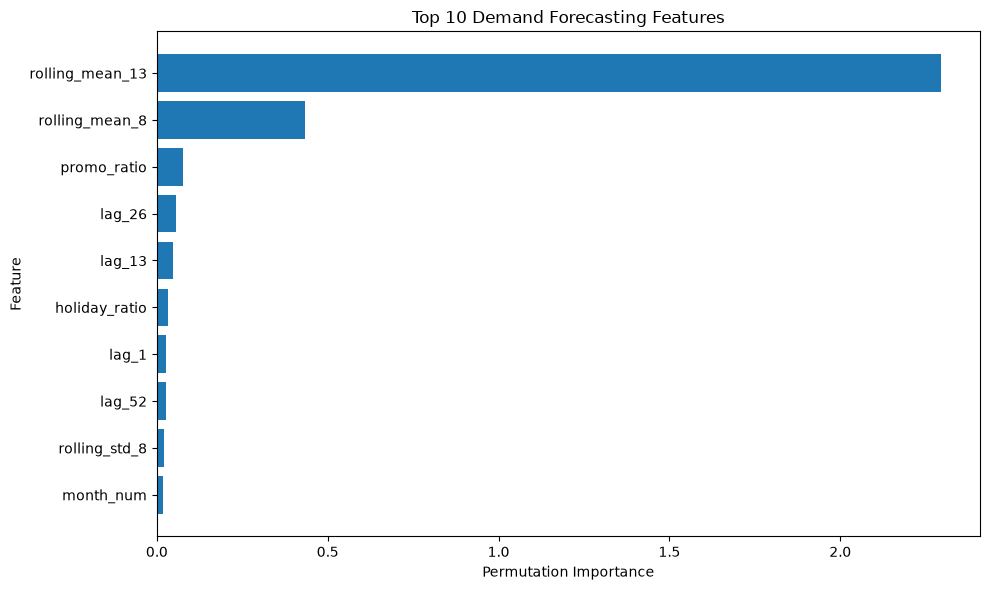

In [58]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10).sort_values(
    "importance_mean"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["feature"],
    top10["importance_mean"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 Demand Forecasting Features")

plt.tight_layout()
plt.show()